In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader

import kagglehub

import time
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

c:\Users\Mike\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [34]:
#adjustable parameters

from Classifiers import NaiveClassifier, PretrainedClassifier

num_epochs   = 150
lr           = 3e-4 #same lr for both to reduce confounding variables
batch_size   = 256
num_classes  = 8    
latent_dim   = 256
weight_decay = 1e-4 #to reduce overfitting

criterion = nn.CrossEntropyLoss()

naive_classifier = NaiveClassifier(num_classes).to(device)
pretrained_classifier = PretrainedClassifier(latent_dim, num_classes).to(device)


naive_optimizer = optim.Adam(naive_classifier.parameters(), lr=lr, weight_decay=weight_decay)
pretrained_optimizer = optim.Adam(pretrained_classifier.parameters(), lr=lr, weight_decay=weight_decay)

In [23]:
#importing images
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#one pathology per image / equal number of images per pathology
full_dataset = kagglehub.dataset_download("obulisainaren/retinal-oct-c8")
full_dataset += '/RetinalOCT_Dataset/RetinalOCT_Dataset' 
train_dataset = ImageFolder(
    root=full_dataset+'/train',
    transform=transform
)

train_loader = DataLoader(
   dataset=train_dataset,
   batch_size=batch_size,
   shuffle=True,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

val_dataset = ImageFolder(
    root= full_dataset+'/val',
    transform=transform
)

#val
val_loader = DataLoader(
   dataset=val_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

#test
test_dataset = ImageFolder(
    root= full_dataset+'/test',
    transform=transform
)

test_loader = DataLoader(
   dataset=test_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

In [ ]:
#training naive
start_time = time.perf_counter()

naive_train_losses = []
naive_val_losses = []

for epoch in range(num_epochs):
    naive_classifier.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        output = naive_classifier(images)
        loss = criterion(output, labels)

        naive_optimizer.zero_grad()
        loss.backward()
        naive_optimizer.step()

        total_loss += loss.item()

        predicted = output.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    end_time = time.perf_counter()
    naive_train_losses.append(epoch_train_loss)

    #val
    naive_classifier.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            output = naive_classifier(images)
            loss = criterion(output, labels)
            
            val_loss += loss.item()

            predicted = output.argmax(dim=1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_accuracy = 100 * val_correct / val_total
    naive_val_losses.append(epoch_val_loss)


    print(
        f"Epoch {epoch+1}: "
        f"Training: Loss={epoch_train_loss:.4f}, "
        f"Accuracy={accuracy:.2f}%      "
        f"Validation: Loss={epoch_val_loss:.4f}, "
        f"Val Acc={epoch_val_accuracy:.2f}%"
    )
    


naive_accuracy = epoch_val_accuracy
naive_train_time = end_time - start_time

print(
    f"Results: Accuracy={naive_accuracy:.2f}% "
    f"Training Duration={naive_train_time:.6f} sec"
)

torch.save(naive_classifier.state_dict(), "naive_classifier.pth")

In [ ]:
plt.plot(naive_train_losses, label="Training Loss")
plt.plot(naive_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [24]:
#Encoding images to latent space
from AutoEncoder import AutoEncoder

weights = torch.load("models\\oct_autoencoder_model.pth", map_location=device)
ae = AutoEncoder(latent_dim=latent_dim)
ae.load_state_dict(weights)
encoder = ae.encoder.to(device)
encoder.eval()

start_time = time.perf_counter()

train_features = []
labels_list = []

with torch.no_grad():
    for images, batch_labels in train_loader:
        images = images.to(device)
        pretrained = encoder(images).flatten(1)
        train_features.append(pretrained.cpu())
        labels_list.append(batch_labels)

train_features = torch.cat(train_features)
all_labels = torch.cat(labels_list)

train_encode_time = time.perf_counter() - start_time

pretrained_dataset = TensorDataset(train_features, all_labels)

pretrained_loader = DataLoader(
    pretrained_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)


#encoding val images
start_time = time.perf_counter()

val_features = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        pretrained = encoder(images).flatten(1)

        val_features.append(pretrained.cpu())
        val_labels.append(labels)

val_features = torch.cat(val_features)
val_labels = torch.cat(val_labels)
val_encode_time = time.perf_counter() - start_time

pretrained_val_dataset = TensorDataset(val_features, val_labels)

pretrained_val_loader = DataLoader(
    dataset=pretrained_val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


print(
    f"Training: {len(train_features)} samples, "
    f"Validation: {len(val_features)} samples"
)

print(
    f"Encoding time: "
    f"Train={train_encode_time:.1f}s, "
    f"Val={val_encode_time:.1f}s"
)

Training: 18400 samples, Validation: 2800 samples
Encoding time: Train=25.3s, Val=17.3s


In [35]:
#training pretrained
start_time = time.perf_counter()

pretrained_train_losses = []
pretrained_val_losses = []

for epoch in range(num_epochs):
    pretrained_classifier.train()
    total_loss = 0
    correct = 0
    total = 0

    for pretrained, labels in pretrained_loader:
        pretrained = pretrained.to(device)
        labels = labels.to(device)

        output = pretrained_classifier(pretrained)
        loss = criterion(output, labels)

        pretrained_optimizer.zero_grad()
        loss.backward()
        pretrained_optimizer.step()

        total_loss += loss.item()

        predicted = output.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = total_loss / len(train_loader)    
    accuracy = 100 * correct / total
    end_time = time.perf_counter() - start_time
    pretrained_train_losses.append(epoch_train_loss)

    #val
    pretrained_classifier.eval()
    
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for pretrained, labels in pretrained_val_loader:
            pretrained, labels = pretrained.to(device), labels.to(device)
            
            output = pretrained_classifier(pretrained)
            loss = criterion(output, labels)
            
            val_loss += loss.item()

            predicted = output.argmax(dim=1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_accuracy = 100 * val_correct / val_total
    pretrained_val_losses.append(epoch_val_loss)
    

    print(
        f"Epoch {epoch+1}: "
        f"Training: Loss={epoch_train_loss:.4f}, "
        f"Accuracy={accuracy:.2f}%      "
        f"Validation: Loss={epoch_val_loss:.4f}, "
        f"Val Acc={epoch_val_accuracy:.2f}%"
    )
    
end_time = time.perf_counter()

pretrained_accuracy = epoch_val_accuracy
pretrained_train_time = end_time - start_time

print(
    f"Results: Accuracy={pretrained_accuracy:.2f}% "
    f"Training Duration={pretrained_train_time:.6f} sec"
)

torch.save(pretrained_classifier.state_dict(), "models/pretrained_classifier.pth")

Epoch 1: Training: Loss=1.8735, Accuracy=24.82%      Validation: Loss=1.6044, Val Acc=38.54%
Epoch 2: Training: Loss=1.5154, Accuracy=37.19%      Validation: Loss=1.3516, Val Acc=43.39%
Epoch 3: Training: Loss=1.3480, Accuracy=39.61%      Validation: Loss=1.2426, Val Acc=46.00%
Epoch 4: Training: Loss=1.2626, Accuracy=42.21%      Validation: Loss=1.1851, Val Acc=48.25%
Epoch 5: Training: Loss=1.2103, Accuracy=43.57%      Validation: Loss=1.1523, Val Acc=48.36%
Epoch 6: Training: Loss=1.1767, Accuracy=44.82%      Validation: Loss=1.1267, Val Acc=50.32%
Epoch 7: Training: Loss=1.1457, Accuracy=46.78%      Validation: Loss=1.1057, Val Acc=49.50%
Epoch 8: Training: Loss=1.1274, Accuracy=47.10%      Validation: Loss=1.0854, Val Acc=51.18%
Epoch 9: Training: Loss=1.1078, Accuracy=48.27%      Validation: Loss=1.0710, Val Acc=51.14%
Epoch 10: Training: Loss=1.0926, Accuracy=49.51%      Validation: Loss=1.0578, Val Acc=53.00%
Epoch 11: Training: Loss=1.0800, Accuracy=50.42%      Validation: Los

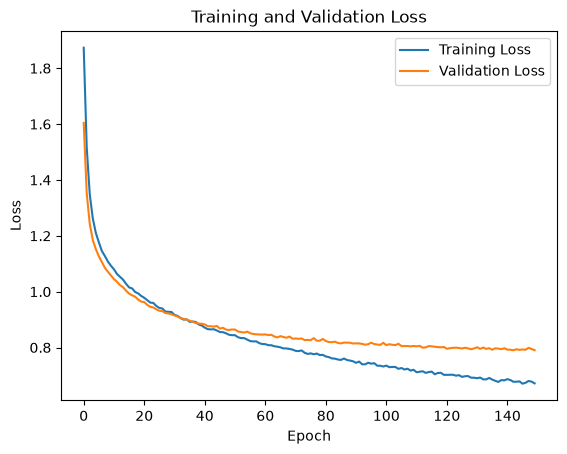

In [36]:
plt.plot(pretrained_train_losses, label="Training Loss")
plt.plot(pretrained_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [39]:
#test - naive

from Classifiers import NaiveClassifier

test_naive_classifier = NaiveClassifier(8).to(device)
test_naive_classifier.load_state_dict(torch.load("models/naive_classifier.pth", map_location=device))
test_naive_classifier.eval()

naive_correct = 0
total = 0
conf_right, conf_wrong = 0.0, 0.0
n_wrong = 0
naive_class_correct = {c: 0 for c in range(num_classes)}
class_total = {c: 0 for c in range(num_classes)}

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = test_naive_classifier(images)
        probs = torch.softmax(logits, dim=1)
        conf, naive_predict = probs.max(dim=1)

        top2 = probs.topk(2, dim=1).indices
        top2_correct += (top2 == labels.unsqueeze(1)).any(dim=1).sum().item()

        hit = (naive_predict == labels)
        naive_correct += hit.sum().item()
        total += labels.size(0)

        conf_right += conf[hit].sum().item()
        conf_wrong += conf[~hit].sum().item()
        n_wrong += (~hit).sum().item()

        for label, e_pred in zip(labels, naive_predict):
            l = label.item()
            class_total[l] += 1
            naive_class_correct[l] += int(l == e_pred.item())

print(f"Naive test accuracy: {100 * naive_correct / total:.2f}%")
print(f"Top-2 accuracy:           {100 * top2_correct / total:.2f}%")
print(f"Mean confidence when right: {conf_right / naive_correct:.3f}")
print(f"Mean confidence when wrong: {conf_wrong / n_wrong:.3f}")
print()
print(f"{'Class':<10} {'Naive':>10}")
for c in range(num_classes):
    name = test_dataset.classes[c]
    e_acc = 100 * naive_class_correct[c] / class_total[c]
    print(f"{name:<10} {e_acc:>9.2f}%")

Naive test accuracy: 50.50%
Top-2 accuracy:           160.46%
Mean confidence when right: 0.571
Mean confidence when wrong: 0.382

Class           Naive
AMD            99.43%
CNV            37.43%
CSR            61.14%
DME            26.00%
DR             27.43%
DRUSEN         28.29%
MH             66.57%
NORMAL         57.71%


In [40]:
#test - pretrained

from Classifiers import PretrainedClassifier

test_pretrained_classifier = PretrainedClassifier(256, 8).to(device)
test_pretrained_classifier.load_state_dict(torch.load("models/pretrained_classifier.pth", map_location=device))
test_pretrained_classifier.eval()

pretrained_correct = 0
top2_correct = 0
total = 0
conf_right, conf_wrong = 0.0, 0.0
n_wrong = 0
pretrained_class_correct = {c: 0 for c in range(num_classes)}
class_total = {c: 0 for c in range(num_classes)}

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = test_pretrained_classifier(encoder(images).flatten(1))
        probs = torch.softmax(logits, dim=1)
        conf, pretrained_predict = probs.max(dim=1)

        top2 = probs.topk(2, dim=1).indices
        top2_correct += (top2 == labels.unsqueeze(1)).any(dim=1).sum().item()

        hit = (pretrained_predict == labels)
        pretrained_correct += hit.sum().item()
        total += labels.size(0)

        conf_right += conf[hit].sum().item()
        conf_wrong += conf[~hit].sum().item()
        n_wrong += (~hit).sum().item()

        for label, e_pred in zip(labels, pretrained_predict):
            l = label.item()
            class_total[l] += 1
            pretrained_class_correct[l] += int(l == e_pred.item())

print(f"Pretrained test accuracy: {100 * pretrained_correct / total:.2f}%")
print(f"Top-2 accuracy:           {100 * top2_correct / total:.2f}%")
print(f"Mean confidence when right: {conf_right / pretrained_correct:.3f}")
print(f"Mean confidence when wrong: {conf_wrong / n_wrong:.3f}")
print()
print(f"{'Class':<10} {'Pretrained':>10}")
for c in range(num_classes):
    name = test_dataset.classes[c]
    e_acc = 100 * pretrained_class_correct[c] / class_total[c]
    print(f"{name:<10} {e_acc:>9.2f}%")

Pretrained test accuracy: 65.89%
Top-2 accuracy:           86.32%
Mean confidence when right: 0.728
Mean confidence when wrong: 0.529

Class      Pretrained
AMD           100.00%
CNV            61.14%
CSR            79.43%
DME            57.71%
DR             54.00%
DRUSEN         50.86%
MH             67.43%
NORMAL         56.57%


In [ ]:
import matplotlib.pyplot as plt

found = {}
for images, labels in val_loader:
    for img, lab in zip(images, labels):
        c = lab.item()
        if c not in found:
            found[c] = img
    if len(found) == 8:
        break

true_ids = sorted(found)
batch = torch.stack([found[c] for c in true_ids])

naive_classifier.eval()
with torch.no_grad():
    pred_ids = naive_classifier(batch.to(device)).argmax(dim=1).cpu().tolist()

class_names = val_loader.dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, t, p in zip(axes.flat, true_ids, pred_ids):
    ax.imshow((found[t].squeeze() + 1) / 2, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"true: {class_names[t]}\npred: {class_names[p]}",
                 color='green' if t == p else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()

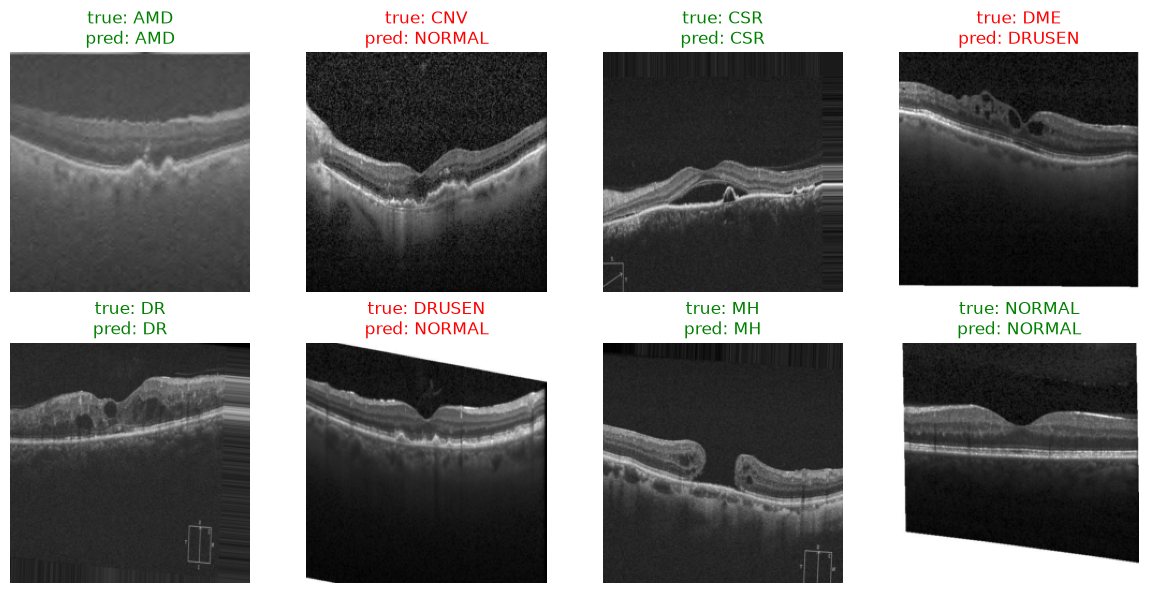

In [21]:
import matplotlib.pyplot as plt

found = {}
for images, labels in val_loader:
    for img, lab in zip(images, labels):
        c = lab.item()
        if c not in found:
            found[c] = img
    if len(found) == 8:
        break

true_ids = sorted(found)
batch = torch.stack([found[c] for c in true_ids])

pretrained_classifier.eval()
with torch.no_grad():
    features = encoder(batch.to(device)).flatten(1)
    pred_ids = pretrained_classifier(features).argmax(dim=1).cpu().tolist()

class_names = val_loader.dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, t, p in zip(axes.flat, true_ids, pred_ids):
    ax.imshow((found[t].squeeze() + 1) / 2, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"true: {class_names[t]}\npred: {class_names[p]}",
                 color='green' if t == p else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()